In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#load dataset

df = pd.read_csv('IPL-checkpoint.csv')

print()
print(df)
df.head()
#checking the dataset is null or not

df.isnull().sum()   #sum()  it gives sum of null values in each column




    match_id           date                                         venue  \
0          1  March 26,2022                      Wankhede Stadium, Mumbai   
1          2  March 27,2022                     Brabourne Stadium, Mumbai   
2          3  March 27,2022            Dr DY Patil Sports Academy, Mumbai   
3          4  March 28,2022                      Wankhede Stadium, Mumbai   
4          5  March 29,2022  Maharashtra Cricket Association Stadium,Pune   
..       ...            ...                                           ...   
69        70    May 22,2022                      Wankhede Stadium, Mumbai   
70        71    May 24,2022                         Eden Gardens, Kolkata   
71        72    May 25,2022                         Eden Gardens, Kolkata   
72        73    May 27,2022              Narendra Modi Stadium, Ahmedabad   
73        74    May 29,2022              Narendra Modi Stadium, Ahmedabad   

        team1      team2    stage toss_winner toss_decision  first_ings_sc

### ***WHO WON THE MOST MATCHES***

Text(0, 0.5, 'Teams')

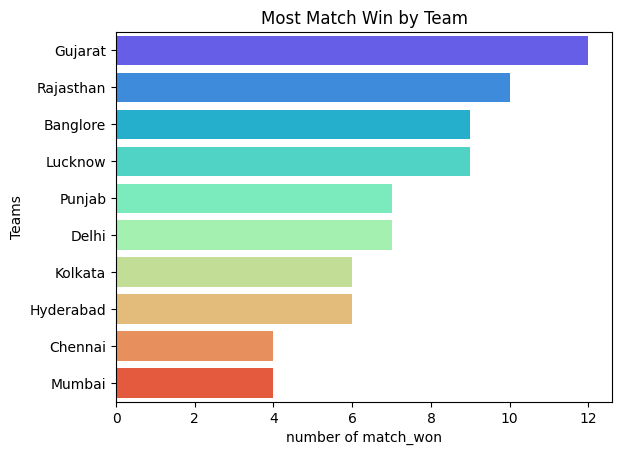

In [19]:
match_wins = df['match_winner'].value_counts()
match_wins

sns.barplot(y = match_wins.index , x = match_wins.values,palette='rainbow')
plt.title('Most Match Win by Team')
plt.xlabel('number of match_won')
plt.ylabel('Teams')

## **Toss Decesion Trends**

Text(0.5, 0, 'choice of toss')

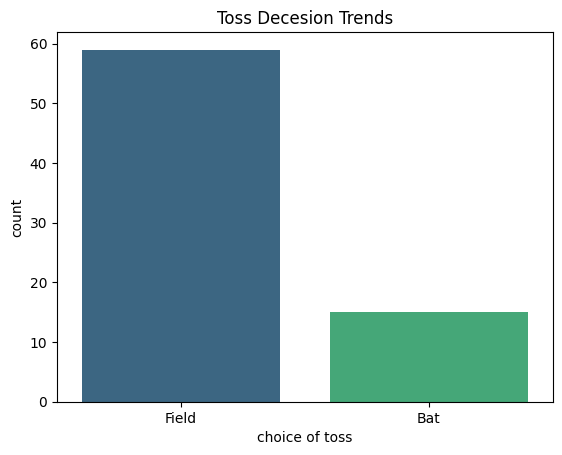

In [22]:
sns.countplot(x = df['toss_decision'],palette='viridis')
plt.title('Toss Decesion Trends')
plt.xlabel('choice of toss')

# **Toss winner vs Match Winner**

In [31]:
count = df[df['match_winner'] == df['toss_winner']]['match_id'].count()
percentage = (count*100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

# **How do Teams Win (Runs or Wickets) **

<Axes: xlabel='won_by', ylabel='count'>

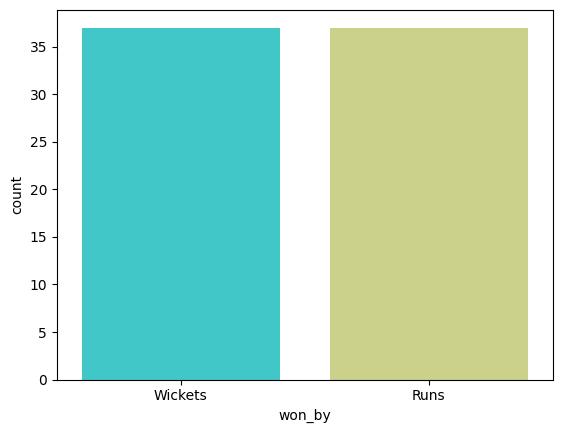

In [33]:
sns.countplot(x = df['won_by'],palette='rainbow')

# **Key Player Performances**

1. Most Player of the Match Award

Text(0, 0.5, 'Players')

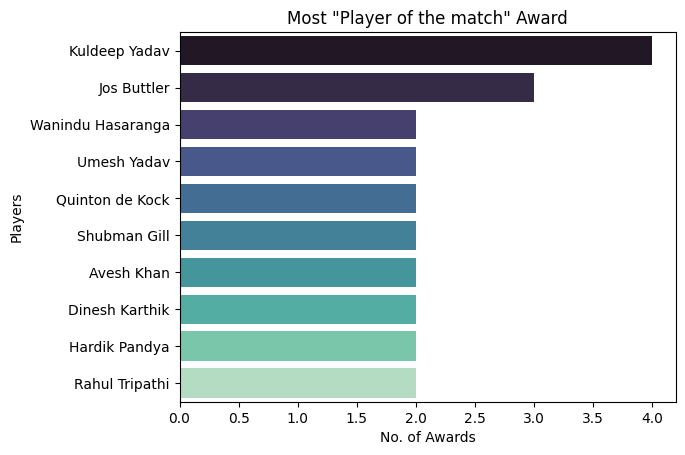

In [47]:
count_player = df['player_of_the_match'].value_counts().head(10)
count_player

sns.barplot(y = count_player.index,x = count_player.values,palette='mako')
plt.title('Most "Player of the match" Award')
plt.xlabel('No. of Awards')
plt.ylabel('Players')

2. Top 2 Scorer

<Axes: ylabel='top_scorer'>

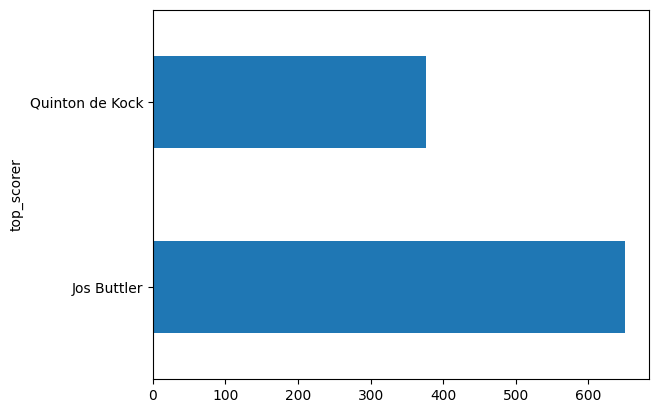

In [51]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

high.plot(kind = 'barh')

3. Top Ten Bowling figures

<Axes: ylabel='best_bowling'>

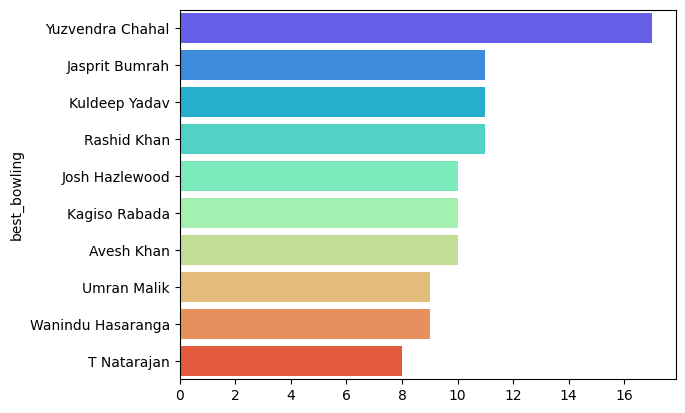

In [58]:
df['Highest_wickets'] = df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['Highest_wickets'] = df['Highest_wickets'].astype(int)
best_bowl = df.groupby('best_bowling')['Highest_wickets'].sum().sort_values(ascending=False).head(10)
best_bowl

sns.barplot(y = best_bowl.index,x = best_bowl.values,palette='rainbow')

4. Most Matches Played by Venue

Text(0.5, 0, 'No. of Matches Played')

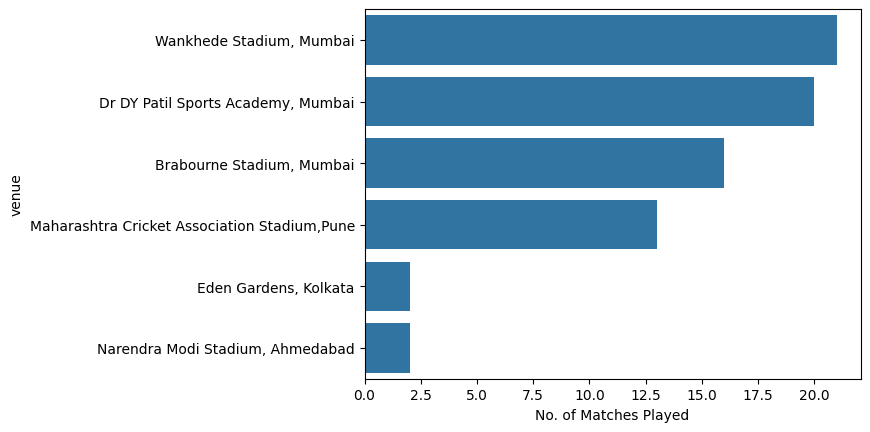

In [61]:
venue_counts = df['venue'].value_counts()
venue_counts

sns.barplot(x= venue_counts.values,y = venue_counts.index)
plt.xlabel('No. of Matches Played')

# **Who Won the highest margin by runs**

In [67]:
df[df['won_by']== 'Runs'].sort_values(by= 'margin',ascending=False)[['match_winner','margin']].head(1)

,match_winner,margin
54,Chennai,91


Who has the highest individual score

In [72]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Best Bowling figures

In [73]:
df

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,Highest_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,...,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26,3
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,...,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14,1
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,...,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43,3
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,...,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22,3


In [76]:
df[df['Highest_wickets'] == df['Highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
